In [1]:
import pandas as pd
from feature_engine.discretisation import DecisionTreeDiscretiser
import matplotlib.pyplot as plt
import funciones
import pygad
import pickle
import numpy as np

In [2]:
#{
#  7000: [  # Lista de corridas para N=7000
#    {
#      'ejecucion': 0,
#      'soluciones': array([[1, 0, 1, ...], ...]), # Matriz (50, 190)
#      'fitness': array([[1.0, 140.0], ...]),      # Matriz (50, 2)
#      'tiempo': 2890.45
#    },
#    { 'ejecucion': 1, ... },
#    { 'ejecucion': 2, ... }
#  ],
#  10000: [ ... ]
#}

df_10k_discretizado = pd.read_csv('df_10k_discretizado.csv', index_col=0)

columnas_features = df_10k_discretizado.columns[:190].tolist()

In [15]:
with open('experimento3_escalabilidad_soluciones.pkl', 'rb') as f:
    experimento3 = pickle.load(f)

In [ ]:
#with open('experimento4.pkl', 'rb') as f:
#    experimento3 = pickle.load(f)

#with open('experimento3_escalabilidad_soluciones.pkl', 'wb') as archivo:
#    pickle.dump(experimento3, archivo)

In [7]:
# Ver el conteo del primer Run (índice 0) de un valor de N (ej. 10000)
cantidad = len(experimento3[10000][0]['soluciones'])

print(cantidad)

50


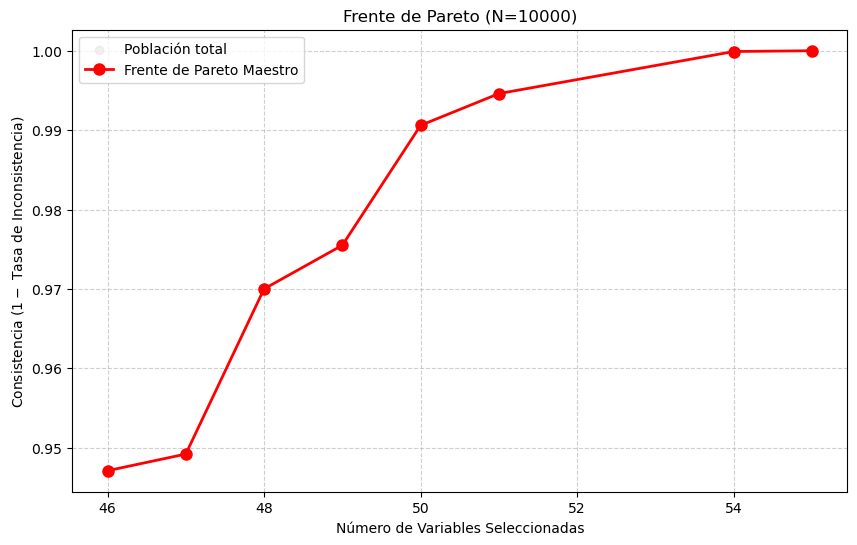

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def obtener_frente_maestro(datos_fitness):
    """
    Filtra soluciones no dominadas para encontrar el frente real.
    datos_fitness: matriz de (N_puntos, 2) -> [consistencia, simplicidad]
    """
    # Ordenar: Mayor consistencia primero, luego mayor simplicidad
    puntos = sorted(datos_fitness, key=lambda x: (x[0], x[1]), reverse=True)
    
    frente = [puntos[0]]
    for p in puntos[1:]:
        # Si el punto actual es más 'simple' (menos variables) que el último del frente
        # (ya es igual o menor en consistencia por el ordenamiento), se agrega.
        if p[1] > frente[-1][1]:
            frente.append(p)
            
    return np.array(frente)

def graficar_frente_maestro_por_n(experimento, n_valor):
    # Juntar todos los fitness de todas las ejecuciones (Runs) de ese N
    todos_los_fitness = np.vstack([run['fitness'] for run in experimento[n_valor]])
    
    #Obtener solo los puntos que forman el Frente de Pareto
    frente = obtener_frente_maestro(todos_los_fitness)
    
    
    # Simplicidad (fitness[1]) = 190 - num_vars
    num_vars_frente = 190 - frente[:, 1]
    consistencia_frente = frente[:, 0]
    
    # Puntos de toda la población
    num_vars_total = 190 - todos_los_fitness[:, 1]
    consistencia_total = todos_los_fitness[:, 0]

    
    plt.figure(figsize=(10, 6))
    
    # Ruido
    plt.scatter(num_vars_total, consistencia_total, color='lightgray', alpha=0.3, label='Población total')
    
    # Frente Maestro
    idx_orden = np.argsort(num_vars_frente) # Ordenamos para que la línea no se cruce
    plt.plot(num_vars_frente[idx_orden], consistencia_frente[idx_orden], 
             '-o', color='red', linewidth=2, markersize=8, label='Frente de Pareto Maestro')

    plt.title(f'Frente de Pareto (N={n_valor})')
    plt.xlabel('Número de Variables Seleccionadas')
    plt.ylabel('Consistencia ($1 -$ Tasa de Inconsistencia)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

# Ejecución para N=600 (donde ya se ve un frente real)
graficar_frente_maestro_por_n(experimento3, 10000)

#with open('experimento4.pkl', 'wb') as archivo:
#    pickle.dump(experimento3, archivo)

In [19]:
#Decodificar soluciones de frente de pareto

def extraer_soluciones_pareto(experimento, n_valor, nombres_columnas):
    # 1. Consolidar fitness y soluciones de todos los Runs para ese N
    todos_fitness = np.vstack([run['fitness'] for run in experimento[n_valor]])
    todas_soluciones = np.vstack([run['soluciones'] for run in experimento[n_valor]])
    
    # 2. Obtener los puntos del frente (fitness)
    frente_fitness = obtener_frente_maestro(todos_fitness)
    
    soluciones_finales = []
    
    # 3. Mapear cada punto del frente de vuelta a sus variables
    for fit in frente_fitness:
        # Buscamos el índice del individuo que tiene este fitness exacto
        # (Usamos np.where para encontrar la coincidencia en ambas columnas)
        idx = np.where((todos_fitness == fit).all(axis=1))[0][0]
        mascara = todas_soluciones[idx]
        
        # Convertir bits a nombres de columnas
        features_seleccionadas = [nombres_columnas[j] for j, bit in enumerate(mascara) if bit == 1]
        
        soluciones_finales.append({
            'consistencia': fit[0],
            'num_vars': int(190 - fit[1]),
            'features': features_seleccionadas
        })
    
    return soluciones_finales

# Uso
soluciones_pareto = extraer_soluciones_pareto(experimento3, 10000, columnas_features)

soluciones_pareto

[{'consistencia': 1.0,
  'num_vars': 55,
  'features': ['T1_charge',
   'T1_p',
   'T1_phi',
   'T1_muonID',
   'T1_protID',
   'T1_nCDCHits',
   'T1_chiProb',
   'T1_EW90',
   'T2_charge',
   'T2_p',
   'T2_cosTheta',
   'T2_muonID',
   'T2_nCDCHits',
   'T2_dz',
   'T2_cosThetaMissCMS',
   'T2_cosTPTO',
   'T3_cosTheta',
   'T3_nCDCHits',
   'T3_nPXDHits',
   'T3_dr',
   'T3_recoilMassSqrd',
   'T4_kaonID',
   'T4_protID',
   'T4_nCDCHits',
   'T4_nSVDHits',
   'T5_charge',
   'T5_cosTheta',
   'T5_nSVDHits',
   'T5_chiProb',
   'T6_nCDCHits',
   'T6_chiProb',
   'T6_EW90',
   'T6_cosThetaMissCMS',
   'T7_cosTheta',
   'T7_nPXDHits',
   'T7_dr',
   'T7_pMissCMS',
   'T8_charge',
   'T8_cosTheta',
   'T8_phi',
   'T8_kaonID',
   'T8_protID',
   'T8_nPXDHits',
   'T8_nSVDHits',
   'T8_EW90',
   'T9_charge',
   'T9_elecID',
   'T9_nSVDHits',
   'T9_dz',
   'T9_pMissCMS',
   'T9_cosThetaMissCMS',
   'T9_cosTPTO',
   'T10_phi',
   'T10_elecID',
   'T10_cosThetaMissCMS']},
 {'consistencia'

In [ ]:
#Elegir solucion del frente

# Opción A: La de máxima consistencia 
mejor_consistencia = max(soluciones_pareto, key=lambda x: x['consistencia'])

#EElegir nimero de variables
mi_seleccion = [s for s in soluciones_pareto if s['num_vars'] == 55][0]

print(f"Entrenando con {mi_seleccion['num_vars']} variables.")
print(f"Features: {mi_seleccion['features'][:6]}...") # Ver las primeras 

Entrenando con 55 variables.
Features: ['T1_charge', 'T1_p', 'T1_phi', 'T1_muonID', 'T1_protID', 'T1_nCDCHits']...


In [ ]:
len(mi_seleccion['features'])

['T1_charge',
 'T1_p',
 'T1_phi',
 'T1_muonID',
 'T1_protID',
 'T1_nCDCHits',
 'T1_chiProb',
 'T1_EW90',
 'T2_charge',
 'T2_p',
 'T2_cosTheta',
 'T2_muonID',
 'T2_nCDCHits',
 'T2_dz',
 'T2_cosThetaMissCMS',
 'T2_cosTPTO',
 'T3_cosTheta',
 'T3_nCDCHits',
 'T3_nPXDHits',
 'T3_dr',
 'T3_recoilMassSqrd',
 'T4_kaonID',
 'T4_protID',
 'T4_nCDCHits',
 'T4_nSVDHits',
 'T5_charge',
 'T5_cosTheta',
 'T5_nSVDHits',
 'T5_chiProb',
 'T6_nCDCHits',
 'T6_chiProb',
 'T6_EW90',
 'T6_cosThetaMissCMS',
 'T7_cosTheta',
 'T7_nPXDHits',
 'T7_dr',
 'T7_pMissCMS',
 'T8_charge',
 'T8_cosTheta',
 'T8_phi',
 'T8_kaonID',
 'T8_protID',
 'T8_nPXDHits',
 'T8_nSVDHits',
 'T8_EW90',
 'T9_charge',
 'T9_elecID',
 'T9_nSVDHits',
 'T9_dz',
 'T9_pMissCMS',
 'T9_cosThetaMissCMS',
 'T9_cosTPTO',
 'T10_phi',
 'T10_elecID',
 'T10_cosThetaMissCMS']

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

X = df_10k_discretizado[mi_seleccion['features']]
y = df_10k_discretizado['target_flavor']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced', 
    penalty='l2', 
    C=1.0, 
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

/home/juan/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/home/juan/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


           train  test
Exactitud   0.58  0.57
F1          0.58  0.57
APS         0.59  0.58
ROC AUC     0.60  0.59

Resumen de Métricas:


/home/juan/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/home/juan/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


,train,test
Exactitud,0.58,0.57
F1,0.58,0.57
APS,0.59,0.58
ROC AUC,0.60,0.59


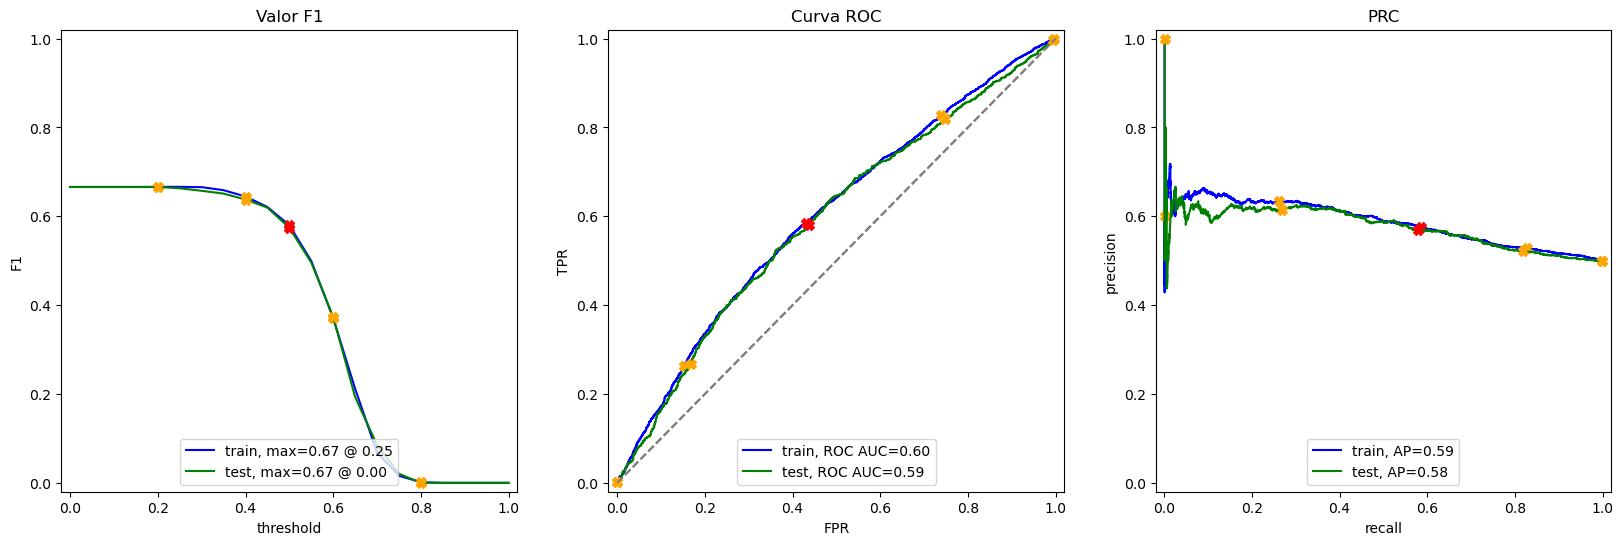

In [31]:
import funciones

stats, figura = funciones.evaluate_model(
    model=log_reg, 
    train_features=X_train, 
    train_target=y_train, 
    test_features=X_test, 
    test_target=y_test
)

print("\nResumen de Métricas:")
display(stats)

In [32]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,            # <--- Evita que el árbol sea demasiado específico
    min_samples_leaf=10,    # <--- Exige que las hojas sean más generales
    max_features='sqrt',    # <--- Solo mira una parte de las 190 variables en cada nodo
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, min_samples_leaf=10, n_jobs=-1,
                       random_state=42)

           train  test
Exactitud   0.66  0.61
F1          0.65  0.61
APS         0.72  0.65
ROC AUC     0.73  0.66

Resumen de Métricas:


,train,test
Exactitud,0.66,0.61
F1,0.65,0.61
APS,0.72,0.65
ROC AUC,0.73,0.66


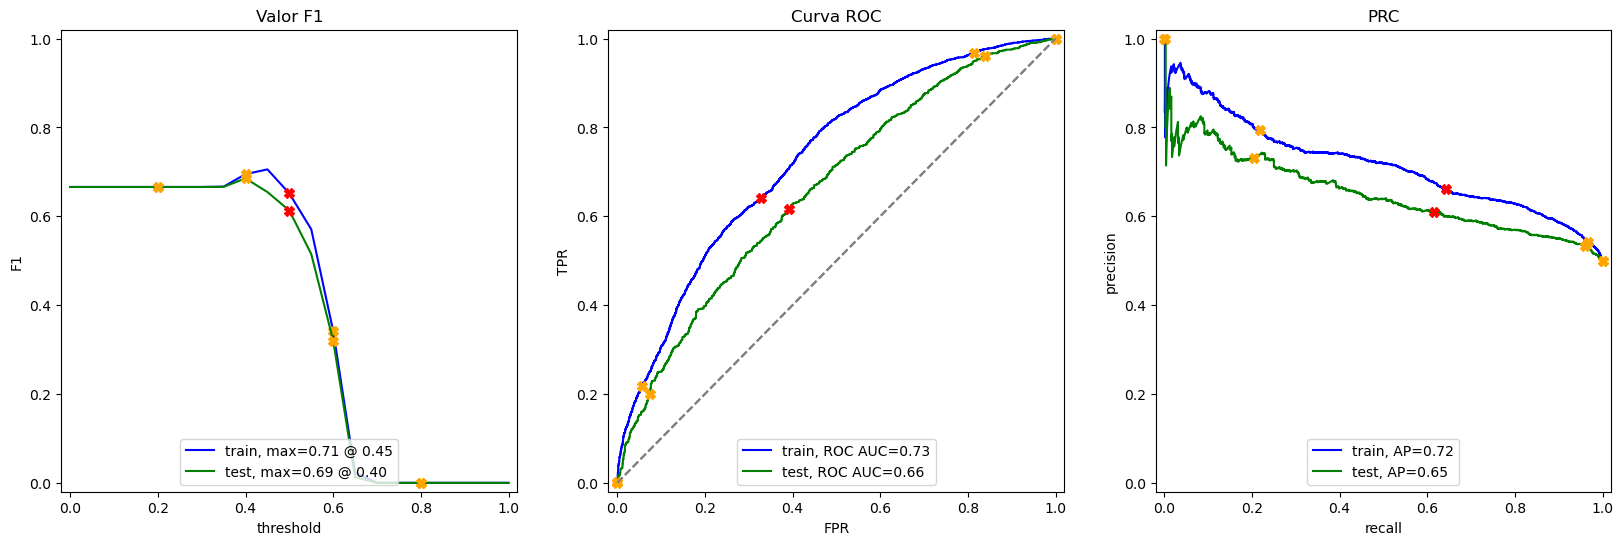

In [33]:
#evaluacion del modelo
stats, figura = funciones.evaluate_model(
    model=model, 
    train_features=X_train, 
    train_target=y_train, 
    test_features=X_test, 
    test_target=y_test
)

print("\nResumen de Métricas:")
display(stats)